# Exercise: RDataFrame and collections

The same dataset used in the previous exercise (`TTree` "dataset" in file `../data/example_file.root`) contains two vector columns `vec1` and `vec2`.<br>
The elements of `vec1` are distributed as a mixture of Gaussians, plus background noise.<br>
To remove the background noise, select the elements of `vec1` for which the square of the corresponding elements in `vec2` is less than 0.1.

Then plot vec1

Where are the peaks of this mixture of Gaussians?

### Useful links

- [RDataFrame: working with collections](https://root.cern/doc/master/classROOT_1_1RDataFrame.html#collections)
- [RVec reference](https://root.cern/doc/master/classROOT_1_1VecOps_1_1RVec.html)

In [1]:
import ROOT
df= ROOT.RDataFrame("dataset","../data/example_file.root")

Welcome to JupyROOT 6.28/00


In [2]:
df.Display().Print()

+-----+------------+------------+------------+--------------+
| Row | a          | b          | vec1       | vec2         | 
+-----+------------+------------+------------+--------------+
| 0   | 0.97771140 | 0.99974175 | -3.22012f  | 0.894402f    | 
+-----+------------+------------+------------+--------------+
| 1   | 2.2802012  | 0.48497361 | -1.80835f  | 0.0800873f   | 
|     |            |            | 0.236065f  | 0.479906f    | 
|     |            |            | -3.97713f  | 0.519888f    | 
|     |            |            | -0.293643f | 0.317273f    | 
+-----+------------+------------+------------+--------------+
| 2   | 0.56348245 | 0.39231399 |            |              | 
+-----+------------+------------+------------+--------------+
| 3   | 3.0421559  | 0.33353925 | 0.727539f  | 0.796610f    | 
|     |            |            | -3.81258f  | 0.331128f    | 
|     |            |            | -2.87416f  | -0.00277938f | 
+-----+------------+------------+------------+--------------

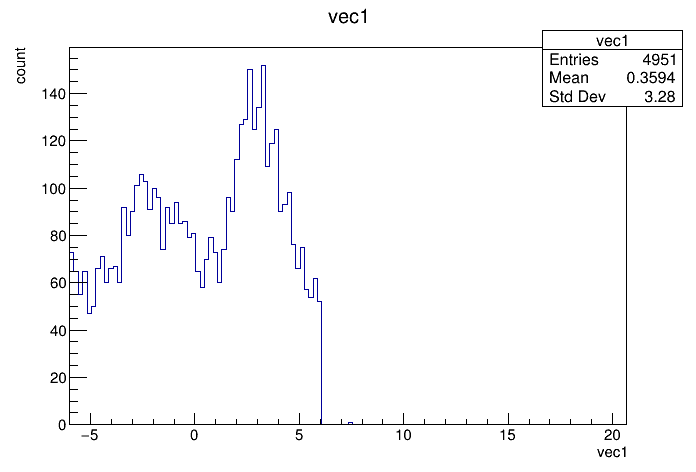

In [3]:
h= df.Histo1D("vec1")
c= ROOT.TCanvas()
h.Draw()
c.Draw()

In [4]:
df_new= df.Define("newcol","vec1[vec2*vec2 < 0.1]")

In [5]:
df_new.Display().Print()

+-----+------------+------------+-----------+------------+--------------+
| Row | a          | b          | newcol    | vec1       | vec2         | 
+-----+------------+------------+-----------+------------+--------------+
| 0   | 0.97771140 | 0.99974175 |           | -3.22012f  | 0.894402f    | 
+-----+------------+------------+-----------+------------+--------------+
| 1   | 2.2802012  | 0.48497361 | -1.80835f | -1.80835f  | 0.0800873f   | 
|     |            |            |           | 0.236065f  | 0.479906f    | 
|     |            |            |           | -3.97713f  | 0.519888f    | 
|     |            |            |           | -0.293643f | 0.317273f    | 
+-----+------------+------------+-----------+------------+--------------+
| 2   | 0.56348245 | 0.39231399 |           |            |              | 
+-----+------------+------------+-----------+------------+--------------+
| 3   | 3.0421559  | 0.33353925 | -2.87416f | 0.727539f  | 0.796610f    | 
|     |            |          

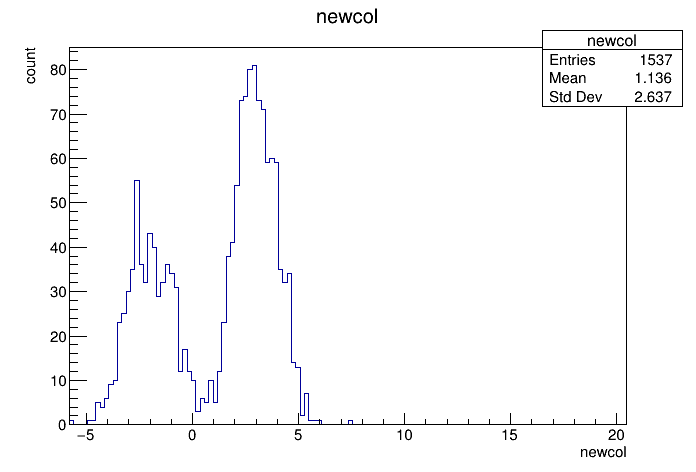

In [6]:
h1= df_new.Histo1D("newcol")
c= ROOT.TCanvas()
h1.Draw()
c.Draw()